In [1]:
# !pip install uproot
# !pip install awkward
# !pip install matplotlib

In [2]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import vector

In [3]:
file = uproot.open('sample_root_files/output_570.root') # Opening file

In [4]:
file.keys()                                             # Printing all trees

['Events;1', 'LuminosityBlocks;1', 'Runs;1', 'untagged;1']

In [5]:
events_tree = file['Events']                            # Assigning events tree to events_tree
# print(events_tree.keys())

In [6]:
eft_coeff = events_tree['EFTfitCoefficients'].array()   # Using EFTfitCoefficients branch and converting it into array

In [7]:
sum_of_coeff = []                                       # Empty list

for coefficient in np.arange(0,len(eft_coeff[0])):
  b = 0                                                 # We will store the total sum of each coefficient in the following step:
  b = np.sum(eft_coeff[:,coefficient])
  sum_of_coeff.append(b)                                # Store the value in the empty list

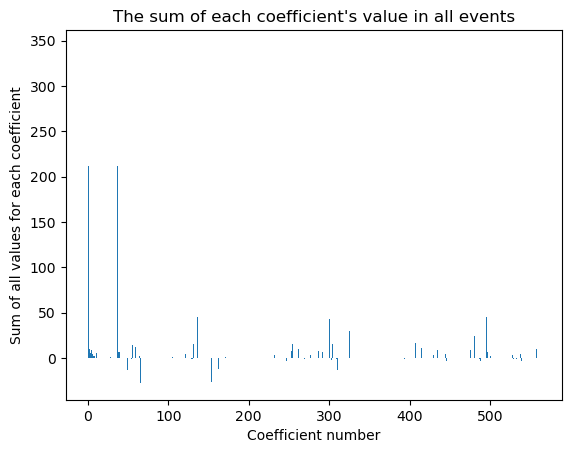

In [8]:
plt.bar(np.arange(1,562),np.array(sum_of_coeff))        # We use plt.bar and not plt.hist since we already have the x and y values!
plt.xlabel('Coefficient number')
plt.ylabel('Sum of all values for each coefficient')
plt.title(r"The sum of each coefficient's value in all events")
plt.show()

In [9]:
# We could also do a (not really informative) histogram of all the values of the coefficients:

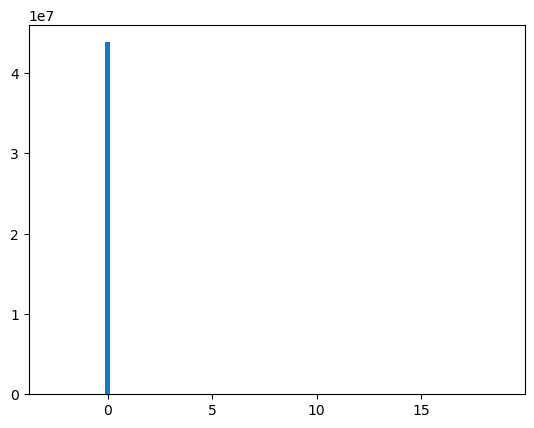

In [10]:
plt.hist(ak.flatten(eft_coeff), bins = 100)
plt.show()

In [11]:
# This is the same graph that appears if we do root!

In [12]:
# let's make a 3D graph with the x-axis as the event number, the y-axis as the number of the coefficient, and
# the color as the value of the coefficient

x_axis = np.arange(1,len(eft_coeff)+1)                  # Setting event number
y_axis = np.arange(1, len(eft_coeff[0])+1)              # Setting coefficient number

b = False
a = 0
asdf = []
while b == False:                                       # This while loop repeats the y_axis so we can assign 156 coefficients to 
    for i in y_axis:                                    # a single number.
        asdf.append(i)
    a += 1
    if a == len(x_axis):
        b = True

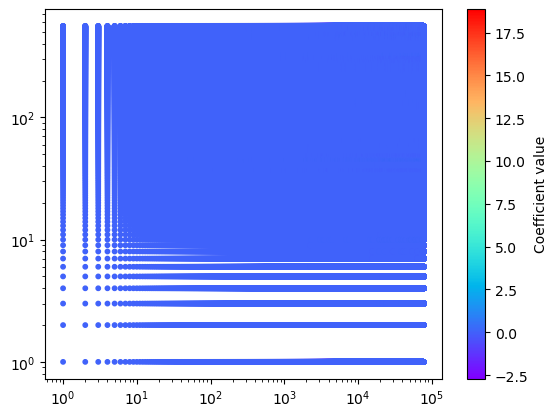

In [13]:
# Graphing the scatter plot (log log plot)

plt.scatter(np.repeat(x_axis, len(y_axis)),np.array(asdf), c = ak.flatten(eft_coeff), cmap='rainbow', s = 10)
plt.yscale('log')
plt.xscale('log')
plt.colorbar(label='Coefficient value')
plt.show()